# HANK with the Sequence-Space Jacobian (SSJ)

**HANK (Heterogeneous-Agent New Keynesian)** models combine the incomplete-markets household block of Krusell-Smith with a New Keynesian (NK) general-equilibrium block: sticky prices (Rotemberg adjustment costs), a Taylor rule for monetary policy, monopolistic competition, and endogenous labor supply. Together, these features make monetary policy shocks non-neutral and create rich heterogeneous transmission channels.

Unlike the KS model — where heterogeneity has negligible aggregate effects (the KS irrelevance result) — in HANK, **household heterogeneity significantly amplifies monetary transmission**. Two key channels operate: (1) **MPC heterogeneity**: high-MPC constrained households respond more strongly to wage and income changes than a representative agent would; (2) **precautionary saving**: the redistribution of income induced by a monetary shock interacts with the precautionary motive across the wealth distribution.

This notebook: (1) calibrates the HANK steady state using a 2D Broyden solve for (β, φ); (2) computes the SSJ Jacobians via the fake-news algorithm; (3) solves for GE impulse responses to a monetary policy shock via the DAG approach; (4) compares to a **near-RA HANK** benchmark (σs ≈ 0, β = 1/(1+r)) to isolate the amplification due to genuine heterogeneity.

> **Reference**: Auclert, A., Bardóczy, B., Rognlie, M., & Straub, L. (2021). Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models. *Econometrica*, 89(5), 2375–2408.

In [1]:
# ── Packages and shared utilities ────────────────────────────────────────────
using Parameters, LinearAlgebra, SparseArrays
using Setfield, ForwardDiff, BasicInterpolators
using NLsolve, Roots, Plots, Colors

include("rouwenhorst.jl")
include("gensys.jl")
include("ssj_utils.jl")   # shared: build_Λ, inv_dist, get_E, build_J

build_J

## 1. Parameters

HANK adds several parameters relative to KS:

- **`φ`** (labor disutility) and **`ν`** (inverse Frisch elasticity): govern the endogenous labor supply.
- **`μ`** (markup): steady-state markup from monopolistic competition; determines the wage `w = 1/μ`.
- **`κ`** (slope of NK Phillips curve): governs the speed of price adjustment.
- **`B`** (government bond supply): pins down the level of assets in the bond market.
- **`θ_π`** (Taylor coefficient): how aggressively the central bank responds to inflation.

Both `β` and `φ` are jointly calibrated via 2D Broyden to hit bond market clearing and aggregate labor equal to the target.

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────

"""
Structural model parameters.

β and φ are calibrated internally to hit bond market clearing at r_target
and aggregate effective labor equal to Y_target.
"""
@with_kw struct ModelParameters{T}
    # household
    β::T    = 0.98                          # discount factor (re-calibrated)
    φ::T    = 0.8                           # labor disutility (re-calibrated)
    σ::T    = 2.0                           # CRRA curvature
    ν::T    = 2.0                           # inverse Frisch elasticity

    # idiosyncratic income process
    ρs::T   = 0.966                         # AR(1) persistence of log-skill
    σs::T   = (1.0 - ρs^2)^0.5 * 0.5       # std of skill innovations

    # firms & policy
    μ::T    = 1.2                           # steady-state markup
    κ::T    = 0.1                           # slope of NK Phillips curve
    B::T    = 5.6                           # government bond supply
    θ_π::T  = 1.5                           # Taylor rule coefficient on inflation
    Z_ss::T = 1.0                           # steady-state TFP

    # calibration targets
    r_target::T = 0.005                     # target real interest rate
    Y_target::T = 1.0                       # target output (= 1 by normalisation)
end

"""
Numerical / discretisation parameters.  Wraps a `ModelParameters` instance.
"""
@with_kw struct NumericalParameters{F,I}
    mp::ModelParameters{F} = ModelParameters()

    # asset grid
    na::I   = 500
    amin::F = 0.0
    amax::F = 150.0

    # idiosyncratic skill grid (Rouwenhorst)
    ns::I             = 7
    Ps::Matrix{F}     = rouwenhorst(ns, mp.ρs, mp.σs)[1]
    s_grid::Vector{F} = exp.(rouwenhorst(ns, mp.ρs, mp.σs)[2])

    # log10 asset grid — denser near the borrowing constraint
    a_grid::Vector{F} = _log10_grid(amin, amax, na)

    tolHH::F = 1e-7     # EGM convergence tolerance
    T::I     = 300      # sequence-space horizon
end

"""Log10 grid on [amin, amax] with `na` points (denser near amin)."""
function _log10_grid(amin, amax, na)
    pivot = 0.25
    grid  = collect(Iterators.map(
                x -> exp10(x) - pivot,
                range(log10(amin + pivot), log10(amax + pivot); length=na)))
    grid[1] = amin
    return grid
end

_log10_grid

## 2. Household Problem — EGM with Endogenous Labor

HANK adds **endogenous labor supply** to the EGM. Each period households choose (c, a', n) jointly. The intratemporal optimality condition (labor-leisure margin) links labor supply to the marginal utility of consumption:

$$n = \left(\frac{w \cdot \text{MU}(c) \cdot s}{\varphi}\right)^{1/\nu}$$

The EGM proceeds as:
1. Compute `EVa` and invert the Euler equation to get `MU_endog = β·EVa`.
2. Apply the intratemporal condition to get `n_endog`; recover `c_endog = MU^{-1/σ}`.
3. Recover the endogenous asset grid from the budget constraint.
4. Interpolate onto the fixed grid; for **constrained** households (`a' = amin`), solve the budget constraint and intratemporal condition jointly via `solve_c_n_constrained`.

In [3]:
# ── Household EGM with endogenous labor ──────────────────────────────────────

"""
    update_EVa(cpol, r, np) → EVa  [na × ns]

Expected marginal utility of savings tomorrow, integrated over Ps.
"""
function update_EVa(cpol::AbstractArray, r::T, np::NumericalParameters) where {T<:Real}
    return (1.0 + r) .* (max.(cpol, 1e-8) .^ (-np.mp.σ)) * np.Ps'
end

"""
    solve_c_n_constrained(a_grid_c, c_guess, ws, r, T_hh, np) → c

Fixed-point iteration to recover consumption of borrowing-constrained households.
For constrained agents, `a' = amin` is fixed, so budget constraint and
intratemporal condition must be solved jointly:
  c = ws·n + T_hh + (1+r)·a − amin
  n = (ws · c^{−σ} / φ)^{1/ν}
"""
function solve_c_n_constrained(a_grid_c, c_guess, ws, r, T_hh, np::NumericalParameters;
                                max_iter::Int=100, tol::Float64=1e-11)
    @unpack mp, amin = np
    @unpack σ, φ, ν  = mp

    dist = Inf; iter = 0
    while iter < max_iter && dist > tol
        n_c       = ((ws .* c_guess .^ (-σ)) ./ φ) .^ (1 / ν)
        c_implied = ws .* n_c .+ T_hh .+ (1 + r) .* a_grid_c .- amin
        dist      = maximum(abs.(c_implied .- c_guess))
        c_guess   = 0.25 .* c_implied .+ 0.75 .* c_guess   # dampened update
        iter     += 1
    end
    iter == max_iter && @warn "solve_c_n_constrained: did not converge."
    return c_guess
end

"""
    EGM_update(cPrime, w, T_hh, r, rPrime, np) → (c, aPrime, n)

One backward EGM step with endogenous labor supply.
"""
function EGM_update(cPrime::AbstractArray, w, T_hh, r, rPrime, np::NumericalParameters)
    @unpack mp, a_grid, s_grid, ns, na, amin = np
    @unpack β, σ, φ, ν = mp

    EVa      = update_EVa(cPrime, rPrime, np)
    MU_endog = β .* EVa

    # intratemporal condition: n = (w · MU · s / φ)^{1/ν}
    n_endog  = ((w .* MU_endog .* s_grid') ./ φ) .^ (1 / ν)
    c_endog  = MU_endog .^ (-1 / σ)

    @assert all(>(0), c_endog) "Negative consumption in EGM."

    inc_endog = w .* s_grid' .* n_endog
    a_endog   = (c_endog .- inc_endog .- T_hh .* s_grid' .+ a_grid) ./ (1.0 + r)
    constr    = a_endog[1, :]

    c  = zeros(eltype(n_endog), na, ns)
    ag = a_grid .+ zeros(eltype(n_endog), 1)

    @views for si in 1:ns
        itp        = LinearInterpolator(a_endog[:, si], c_endog[:, si], NoBoundaries())
        c[:, si]   = itp.(ag)

        constr_idx = a_grid .< constr[si]
        if any(constr_idx)
            c[constr_idx, si] = solve_c_n_constrained(
                a_grid[constr_idx], c[constr_idx, si],
                w * s_grid[si], r, T_hh * s_grid[si], np)
        end
    end

    n      = ((w .* c .^ (-σ) .* s_grid') ./ φ) .^ (1 / ν)
    aPrime = (1 + r) .* a_grid .+ (w .* n .+ T_hh) .* s_grid' .- c
    aPrime = max.(aPrime, amin)

    return c, aPrime, n
end

"""
    solve_EGM_SS(cGuess, wSS, rSS, T_hh, np; max_iter, verbose) → (c, a, n)

Iterate EGM to convergence from `cGuess`.
"""
function solve_EGM_SS(cGuess::AbstractArray, wSS, rSS, T_hh, np::NumericalParameters;
                      max_iter::Int=3000, verbose::Bool=false)
    c0 = copy(cGuess)
    local c1, a1, n1
    dist = Inf; iter = 0

    while dist > np.tolHH && iter < max_iter
        c1, a1, n1 = EGM_update(c0, wSS, T_hh, rSS, rSS, np)
        dist       = maximum(abs.(c1 .- c0))
        verbose && rem(iter, 100) == 0 &&
            println("  iter $iter  |  dist = $(round(dist; sigdigits=3))")
        c0   = copy(c1)
        iter += 1
    end

    iter == max_iter && @warn "solve_EGM_SS: did not converge (dist=$(round(dist;sigdigits=3)))."
    return c1, a1, n1
end

"""
    solve_EGM_SS(wSS, rSS, T_hh, np; kwargs...) → (c, a, n)

Convenience wrapper with automatic initial guess.
"""
function solve_EGM_SS(wSS, rSS, T_hh, np::NumericalParameters; kwargs...)
    incs    = wSS .* np.s_grid
    c_guess = max.(1e-6, 0.1 .+ 0.1 .* ((1 + rSS) .* np.a_grid .+ incs'))
    return solve_EGM_SS(c_guess, wSS, rSS, T_hh, np; kwargs...)
end

solve_EGM_SS

## 3. Distribution

The joint distribution over (asset, skill) is propagated forward by the sparse transition matrix `build_Λ`. The invariant distribution is found by `inv_dist`.

<!-- build_Λ and inv_dist are defined in ssj_utils.jl -->

## 4. Steady-State Calibration

HANK requires jointly calibrating **two** parameters:
- **`β`**: to clear the bond market — aggregate household asset demand `A_ss = B`.
- **`φ`**: to hit the labor target — aggregate effective labor `L_ss = Y_target / Z_ss`.

These are coupled (both affect household choices simultaneously), requiring a **2D Broyden** solve. The `β_φ_objective` function returns the two residuals, and `get_steady_state` wraps the solver.

For the **near-RA** benchmark, the Broyden system is ill-conditioned because near-RA households are nearly indifferent about the level of their savings. Instead, `get_steady_state_nra` fixes `β = 1/(1+r)` from the RA Euler equation and calibrates only `φ` via 1D bisection.

In [4]:
# ── Steady-state calibration (HA) ────────────────────────────────────────────

"""
    β_φ_objective(β, φ, p, np) → [residual_A, residual_L]

Residuals for the (β, φ) calibration system:
  1. Bond market: A_ss / B − 1 = 0
  2. Labour market: L_ss / Y_target − 1 = 0
"""
function β_φ_objective(β, φ, p, np::NumericalParameters)
    w_ss, r_ss, T_hh_ss = p
    @set! np.mp.β = β
    @set! np.mp.φ = φ

    try
        c_ss, a_ss, n_ss = solve_EGM_SS(w_ss, r_ss, T_hh_ss, np)
        Λ      = build_Λ(a_ss, np)
        D      = reshape(inv_dist(Λ), np.na, np.ns)
        A_ss   = sum(D .* a_ss)
        L_ss   = sum(D .* (n_ss .* np.s_grid'))
        return [(A_ss / np.mp.B) - 1, (L_ss / np.mp.Y_target) - 1]
    catch
        return [1e4, 1e4]
    end
end

"""
    get_steady_state(np) → NamedTuple

Calibrate (β, φ) via Broyden's method and return all steady-state objects.

Targets: r_ss = r_target, Y_ss = Y_target, L_ss = Y_target / Z_ss.
"""
function get_steady_state(np::NumericalParameters)
    # normalise average skill to 1
    s_dist = inv_dist(np.Ps)
    @set! np.s_grid = np.s_grid ./ sum(s_dist .* np.s_grid)

    @unpack mp, s_grid, na, ns = np
    @unpack μ, B, Y_target, r_target, Z_ss = mp

    r_ss     = r_target
    Y_ss     = Y_target
    L_ss     = Y_ss / Z_ss
    w_ss     = 1.0 / μ
    div_ss   = Y_ss - w_ss * L_ss
    τ_ss     = r_target * B
    T_hh_ss  = div_ss - τ_ss

    println("Calibrating β and φ via Broyden's method...")
    result = nlsolve(
        (F, x) -> (F .= β_φ_objective(x[1], x[2], [w_ss, r_ss, T_hh_ss], np)),
        [mp.β, mp.φ];
        method=:broyden, ftol=1e-4, show_trace=true)

    !converged(result) && @warn "Calibration (β, φ) did not converge."
    β_cal, φ_cal = result.zero
    println("Calibrated  β = $(round(β_cal; digits=6)),  φ = $(round(φ_cal; digits=6))")

    @set! np.mp.β = β_cal
    @set! np.mp.φ = φ_cal

    c_ss, a_ss, n_ss = solve_EGM_SS(w_ss, r_ss, T_hh_ss, np)
    Λ_ss   = build_Λ(a_ss, np)
    D_ss   = reshape(inv_dist(Λ_ss), na, ns)

    A_ss   = sum(D_ss .* a_ss)
    L_ss   = sum(D_ss .* (n_ss .* s_grid'))
    N_ss   = sum(D_ss .* n_ss)
    C_ss   = sum(D_ss .* c_ss)

    println("SS: A=$(round(A_ss;digits=3))  L=$(round(L_ss;digits=3))  " *
            "C=$(round(C_ss;digits=3))  B=$(round(B;digits=3))")
    println("Goods market clearing residual: $(round(abs(C_ss - Y_ss); sigdigits=4))")

    return (; r_ss, w_ss, Y_ss, L_ss, N_ss, C_ss, A_ss,
              τ_ss, div_ss, T_hh_ss,
              c_ss, a_ss, n_ss, Λ_ss, D_ss, np)
end

get_steady_state

In [5]:
# ── Why near-RA does not work for HANK ──────────────────────────────────────
# In KS, capital has a marginal product r+δ that pins down an interior
# equilibrium even without income risk.  In HANK, bonds are a pure store
# of value with exogenously targeted r.  With σs ≈ 0 (no precautionary
# motive) and β < 1/(1+r), agents drift to amin — no interior equilibrium.
# With β = 1/(1+r) exactly, bond demand is indeterminate.  Either way,
# all agents pile at amin, effective MPC = 1, and the near-RA IRF is
# LARGER than HANK — the opposite of the desired benchmark.
#
# The correct RA benchmark for HANK is the standard 3-equation RANK model
# (IS curve + NKPC + Taylor rule) solved via gensys.  See Section 7.

get_steady_state_nra

## 5. SSJ Building Blocks

The HANK household block maps three input sequences — wage `w`, real rate `r`, and net transfers `T_hh` — to two output sequences: aggregate assets `A` and aggregate effective labor `L`. This richer input structure reflects the NK block's channels:

- **`w`**: wage affects labor income directly and through the intratemporal condition.
- **`r`**: the real rate affects asset returns and (via the Taylor rule) the transfer channel.
- **`T_hh`**: dividends minus taxes affect disposable income.

`backward_objective` records both `A_terms` and `L_terms`; `get_𝒴_𝒟` returns a 3×2 matrix of impulse vectors and a vector of 3 distribution impulse matrices. `build_J` (from `ssj_utils.jl`) is called for each (input, output) pair.

In [5]:
# ── SSJ backward iteration and Y, D impulses ─────────────────────────────────

"""
    backward_objective(dx_w, dx_r, dx_T, c_ss, w_ss, r_ss, T_hh_ss, D_ss, np)
        → vcat(A_terms, L_terms, D_terms[:])

Backward iteration for the fake-news algorithm.

Perturbs (w, r, T_hh) at date T by (dx_w, dx_r, dx_T) and propagates backward.
Records at each date t:
  - A_terms[t]   : aggregate asset response
  - L_terms[t]   : aggregate effective labour response
  - D_terms[:,t] : distribution response
"""
function backward_objective(dx_w, dx_r, dx_T, c_ss, w_ss, r_ss, T_hh_ss, D_ss,
                            np::NumericalParameters)
    @unpack T, s_grid = np
    type_ind = dx_w + dx_r + dx_T

    A_terms = zeros(eltype(type_ind), T)
    L_terms = zeros(eltype(type_ind), T)
    D_terms = zeros(eltype(type_ind), length(D_ss), T)

    c_nc = EGM_update(c_ss, w_ss, T_hh_ss, r_ss, r_ss, np)[1]
    c_rc = copy(c_ss)

    for tt in Iterators.reverse(1:T)
        if tt == T
            c_t, aPrime_t, n_t = EGM_update(c_rc, w_ss + dx_w, T_hh_ss + dx_T,
                                             r_ss + dx_r, r_ss, np)
        elseif tt == T - 1
            c_t, aPrime_t, n_t = EGM_update(c_rc, w_ss, T_hh_ss, r_ss, r_ss + dx_r, np)
        else
            c_t, aPrime_t, n_t = EGM_update(c_rc, w_ss, T_hh_ss, r_ss, r_ss, np)
        end

        Λ = build_Λ(aPrime_t, np)
        D_flat         = vec(D_ss)
        A_terms[tt]    = dot(vec(aPrime_t), D_flat)
        L_terms[tt]    = dot(vec(n_t .* s_grid'), D_flat)
        D_terms[:, tt] = Λ' * D_flat

        c_rc = c_ss .+ (c_t .- c_nc)
    end

    return vcat(A_terms, L_terms, vec(D_terms))
end

"""
    get_𝒴_𝒟(c_ss, w_ss, r_ss, T_hh_ss, D_ss, np) → (𝒴, 𝒟)

Differentiate `backward_objective` w.r.t. (dx_w, dx_r, dx_T) at zero via ForwardDiff.

Returns:
  𝒴[i, 1] : aggregate asset impulse to input i   [T]
  𝒴[i, 2] : aggregate labour impulse to input i  [T]
  𝒟[i]    : distribution impulse to input i      [na·ns × T]
"""
function get_𝒴_𝒟(c_ss, w_ss, r_ss, T_hh_ss, D_ss, np::NumericalParameters)
    @unpack T, na, ns = np

    obj(x) = backward_objective(x[1], x[2], x[3], c_ss, w_ss, r_ss, T_hh_ss, D_ss, np)
    derivs  = ForwardDiff.jacobian(obj, zeros(3))

    𝒴 = Matrix{Vector{Float64}}(undef, 3, 2)
    𝒟 = Vector{Matrix{Float64}}(undef, 3)

    for ii in 1:3
        𝒴[ii, 1] = reverse(derivs[1:T,       ii])
        𝒴[ii, 2] = reverse(derivs[(T+1):2T,  ii])
        𝒟[ii]    = reverse(reshape(derivs[(2T+1):end, ii], (na * ns, T)); dims=2)
    end

    return 𝒴, 𝒟
end

get_𝒴_𝒟

## 6. GE Jacobian via DAG

The GE system is assembled as a **directed acyclic graph (DAG)** of blocks:

- **Firm block**: `Y = Z·L`, `w = 1/μ`, dividends `d = Y - w·L`.
- **Fiscal block**: taxes `τ = r·B`, net transfer `T_hh = d - τ`.
- **NK Phillips curve** (T1): `κ·w_t + β·π_{t+1} − π_t = 0`.
- **Labour market clearing** (T2): `L_t = 𝒩_t` (firm demand = household supply).
- **Asset market clearing** (T3): `A_t = B`.

The three markets give three T-vectors of equilibrium conditions, stacked into a `3T × 3T` system in the endogenous variables `[π, Y, w]`. The monetary policy shock enters through the Taylor rule → real rate → household block.

In [6]:
# ── GE Jacobian assembly ──────────────────────────────────────────────────────

"""
    build_all_jacobians(SS_objs) → Js  [3 × 2 Matrix of T×T matrices]

Compute all HA Jacobians needed for GE:
  Js[i, 1] : Jacobian of aggregate assets  w.r.t. input i ∈ {w, r, T_hh}
  Js[i, 2] : Jacobian of aggregate labour  w.r.t. input i
"""
function build_all_jacobians(SS_objs)
    @unpack c_ss, w_ss, r_ss, T_hh_ss, D_ss, a_ss, n_ss, Λ_ss, np = SS_objs

    println("Computing HA Jacobians via ForwardDiff (this may take a few minutes)...")
    𝒴s, 𝒟s = get_𝒴_𝒟(c_ss, w_ss, r_ss, T_hh_ss, D_ss, np)

    Js = Matrix{Matrix{Float64}}(undef, 3, 2)

    for oo in 1:2
        y_ss = oo == 1 ? a_ss : n_ss .* np.s_grid'
        𝓔    = get_E(Λ_ss, y_ss, np.T)
        for ii in 1:3
            Js[ii, oo] = build_J(𝒴s[ii, oo], 𝒟s[ii], 𝓔, np.T)[1]
        end
    end

    println("Done.")
    return Js
end

"""
    get_GE_jacobians(Js, SS_objs) → (F_x, F_RShock)

Assemble the full GE Jacobian F_x (endogenous → targets) and
F_RShock (monetary shock → targets) from the HA Jacobians Js.

Endogenous variables: [π, Y, w]   (each a length-T sequence)
Three market-clearing conditions: NK Phillips curve, labour, asset markets.
"""
function get_GE_jacobians(Js, SS_objs)
    @unpack np, w_ss, Y_ss, L_ss, r_ss = SS_objs
    @unpack mp, T = np
    @unpack B, μ, θ_π, κ, Z_ss = mp

    I_sp = sparse(I, T, T)
    sp0  = spzeros(T, T)

    dL_dY = 1 / Z_ss
    dd_dY = 1 - w_ss * dL_dY
    dd_dw = -L_ss

    dr_dπ     = spdiagm(-1 => fill(θ_π,     T-1),
                         0 => fill(-(1+r_ss), T))
    dr_dRShock = spdiagm(-1 => ones(T-1))

    dτ_dr = B

    # Target 1: NK Phillips curve
    dT1_π = spdiagm(0 => fill(-1.0, T), 1 => fill(1/(1+r_ss), T-1))
    dT1_w = κ * I_sp

    # Target 2: Labour market
    F_π_T2 = -(Js[2, 2] .- Js[3, 2] .* dτ_dr) * dr_dπ
    F_Y_T2 = dL_dY .* I_sp .- Js[3, 2] .* dd_dY
    F_w_T2 = -(Js[1, 2] .+ dd_dw .* Js[3, 2])

    # Target 3: Asset market
    F_π_T3 = -(Js[2, 1] .- Js[3, 1] .* dτ_dr) * dr_dπ
    F_Y_T3 = Js[3, 1] .* dd_dY
    F_w_T3 = -(Js[1, 1] .+ dd_dw .* Js[3, 1])

    F_x = [dT1_π   sp0    dT1_w;
           F_π_T2  F_Y_T2 F_w_T2;
           F_π_T3  F_Y_T3 F_w_T3]

    F_RShock = vcat(
        sp0,
        -(Js[2, 2] .- Js[3, 2] .* dτ_dr) * dr_dRShock,
        -(Js[2, 1] .- Js[3, 1] .* dτ_dr) * dr_dRShock
    )

    return F_x, F_RShock
end

get_GE_jacobians

## 7. RANK Benchmark (gensys)

As an additional benchmark, we solve the standard **3-equation RANK** model (IS curve, NKPC, Taylor rule) using `gensys`. In RANK, all heterogeneity is absent: there is a single representative agent with the RA Euler equation `β(1+r) = 1`. This provides the pure NK model response to a monetary shock without any precautionary saving or MPC heterogeneity channels.

In [7]:
# ── RANK benchmark via gensys ─────────────────────────────────────────────────

"""
    solve_RANK_gensys(np, ρ_shock) → (π=irf_π, Y=irf_Y, w=irf_w, r=irf_r)

Solve the standard 3-equation RANK model via gensys for a −25bp monetary
policy shock with persistence ρ_shock.

  IS curve:    ŷ_t = E_t ŷ_{t+1} − (1/σ)(r̂_t − E_t π_{t+1})
  NKPC:        π_t = β E_t π_{t+1} + κ ŷ_t
  Taylor rule: r̂_t = θ_π π_t + ε_t

Units: π and r in basis points (×10000), Y and w in % dev. SS (×100).
"""
function solve_RANK_gensys(np::NumericalParameters, ρ_shock::Real)
    @unpack mp = np
    @unpack σ, κ, θ_π = mp
    β = 1.0 / (1.0 + mp.r_target)

    iy, iπ, ir, iEy, iEπ, iε = 1, 2, 3, 4, 5, 6
    n  = 6; nε = 1; nη = 2

    Γ0 = zeros(n, n); Γ1 = zeros(n, n)
    Ψ  = zeros(n, nε); Π = zeros(n, nη); c = zeros(n)

    # eq1: expectational error for output
    Γ0[1, iy] =  1.0; Γ1[1, iEy] = 1.0; Π[1, 1] = 1.0
    # IS curve
    Γ0[2, iEy] = 1.0; Γ0[2, iy] = -1.0; Γ0[2, ir] = -1/σ; Γ0[2, iEπ] = 1/σ
    # eq3: expectational error for inflation
    Γ0[3, iπ] =  1.0; Γ1[3, iEπ] = 1.0; Π[3, 2] = 1.0
    # NKPC
    Γ0[4, iEπ] = 1.0; Γ0[4, iπ] = -1/β; Γ0[4, iy] = κ/β
    # Taylor rule
    Γ0[5, ir] = 1.0; Γ0[5, iπ] = -θ_π; Γ0[5, iε] = -1.0
    # shock process
    Γ0[6, iε] = 1.0; Γ1[6, iε] = ρ_shock; Ψ[6, 1] = 1.0

    G1, _, impact, eu = gensys(Γ0, Γ1, c, Ψ, Π)
    eu[1] != 1 && @warn "RANK gensys: no existence  (eu=$(eu))"
    eu[2] != 1 && @warn "RANK gensys: no uniqueness (eu=$(eu))"

    T = np.T
    x = zeros(n, T)
    x[:, 1] = real(impact) * [-0.0025]   # −25bp shock
    for tt in 2:T
        x[:, tt] = G1 * x[:, tt-1]
    end

    irf_π = 10_000 .* x[iπ, :]
    irf_Y = 100    .* x[iy, :]
    irf_w = 100    .* x[iy, :]   # ŵ = ŷ in log-linear RANK
    irf_r = 10_000 .* x[ir, :]

    return (π=irf_π, Y=irf_Y, w=irf_w, r=irf_r)
end

solve_RANK_gensys

## 8. Plots

In [8]:
# ── Plot functions ─────────────────────────────────────────────────────────────

"""
    plot_hank_vs_nra(hank_irf, nra_irf, ρ; T_plot, save_path)

Compare HANK and near-RA HANK impulse responses to a monetary policy shock.
The gap HANK − near-RA isolates genuine HA amplification.
"""
function plot_hank_vs_nra(hank_irf::NamedTuple, nra_irf::NamedTuple, ρ::Real;
                           T_plot::Int=20,
                           save_path::Union{String,Nothing}=nothing)
    tt  = 1:T_plot
    lw  = 2.5

    function panel(h, n, ylab, title)
        p = plot(tt, h[tt]; lw, color=:steelblue, label="HANK",
                 xlabel="quarters", ylabel=ylab, title=title,
                 legend=:topright, grid=true, gridalpha=0.3)
        plot!(p, tt, n[tt]; lw, color=:darkorange, label="RA", ls=:dashdot)
        return p
    end

    p1 = panel(hank_irf.π, nra_irf.π, "basis points", "Inflation  π")
    p2 = panel(hank_irf.Y, nra_irf.Y, "% dev. SS",    "Output  Y")
    p3 = panel(hank_irf.w, nra_irf.w, "% dev. SS",    "Wage  w")
    p4 = panel(hank_irf.r, nra_irf.r, "basis points", "Real rate  r")

    fig = plot(p1, p2, p3, p4;
               layout=(2, 2), size=(900, 620),
               plot_title="HANK vs RA — monetary shock (ρ=$ρ)",
               left_margin=5Plots.mm, bottom_margin=5Plots.mm)

    !isnothing(save_path) && savefig(fig, save_path)
    return fig
end

plot_hank_vs_nra

## 9. Main Script

### Step 1: HA Steady State

In [9]:
# ── Step 1: Calibrate HA steady state ────────────────────────────────────────
println("=" ^ 60)
println("Step 1: Steady-state calibration")
println("=" ^ 60)

np_base  = NumericalParameters()
@time SS_objs = get_steady_state(np_base)

Step 1: Steady-state calibration
Calibrating β and φ via Broyden's method...
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     2.406464e-01              NaN
     1     1.081634e+00     5.656260e-05
     2     1.135119e-01     6.102386e-05
     3     9.943991e-03     1.259993e-04
     4     9.318489e-03     3.085880e-06
     5     1.196376e-02     1.191741e-05
     6     1.247228e-02     3.787992e-05
     7     4.700632e-03     3.411645e-04
     8     1.627494e-03     8.486428e-08
     9     6.286306e-04     6.405738e-10
    10     4.173419e-05     1.606408e-10
Calibrated  β = 0.982243,  φ = 0.786434
SS: A=5.6  L=1.0  C=1.0  B=5.6
Goods market clearing residual: 1.183e-6
 23.589579 seconds (43.76 M allocations: 14.139 GiB, 4.93% gc time, 22.19% compilation time)


(r_ss = 0.005, w_ss = 0.8333333333333334, Y_ss = 1.0, L_ss = 0.9999999824545363, N_ss = 1.0337834580414909, C_ss = 0.9999988168221626, A_ss = 5.599766288561346, τ_ss = 0.027999999999999997, div_ss = 0.16666666666666663, T_hh_ss = 0.13866666666666663, c_ss = [0.35524804602661936 0.4852841693193759 … 1.3218497003050946 1.5661371904737267; 0.35695967216519453 0.48700403205776377 … 1.3219011712311977 1.566177046378511; … ; 2.6571912690833965 2.696568828402967 … 2.986441026044663 3.122218232717469; 2.679148978967787 2.718309722392764 … 3.006730601981752 3.141933951450217], a_ss = [0.0 0.0 … 0.7886081660940922 1.7052983190311097; 0.0 0.0 … 0.7917277920716792 1.708428301317523; … ; 146.24757673031976 146.26125238713678 … 146.9282391914614 147.55260830510215; 148.14917208980305 148.1627938082915 … 148.826376666251 149.44781026260475], n_ss = [1.4761811639015865 1.3253336444287074 … 1.1008780938110074 1.1395712761424388; 1.4691028565676503 1.3206532068944359 … 1.100835228870535 1.13954227645534

### Step 2: HA Jacobians

In [10]:
# ── Step 2: Build all HA Jacobians ────────────────────────────────────────────
println("\n", "=" ^ 60)
println("Step 2: HA Jacobians")
println("=" ^ 60)

@time Js = build_all_jacobians(SS_objs)


Step 2: HA Jacobians
Computing HA Jacobians via ForwardDiff (this may take a few minutes)...
Done.
  4.989440 seconds (31.77 M allocations: 4.634 GiB, 11.72% gc time, 85.31% compilation time)


3×2 Matrix{Matrix{Float64}}:
 [1.27829 -0.0612636 … -6.69327e-8 -6.38356e-8; 1.22361 1.22478 … -1.3568e-7 -1.29402e-7; … ; 0.000189977 0.000190101 … 0.6345 -0.680062; 0.000184464 0.000184584 … 0.61004 0.6345]          …  [0.475968 -0.03379 … -3.8703e-8 -3.69121e-8; -0.0336465 0.480421 … -3.95634e-8 -3.77326e-8; … ; -3.22157e-6 -3.22368e-6 … 0.497262 -0.0159698; -3.12807e-6 -3.13012e-6 … -0.0157998 0.497262]
 [5.4459 0.627694 … 7.28182e-7 6.9449e-7; 5.32266 6.04437 … 1.4761e-6 1.4078e-6; … ; 0.00121336 0.00133093 … 13.6065 8.44169; 0.00117814 0.0012923 … 13.2146 13.6065]                           [-0.078495 0.345708 … 4.21054e-7 4.01571e-7; -0.0762631 -0.0962323 … 4.30411e-7 4.10496e-7; … ; -2.05769e-5 -2.25707e-5 … -0.24782 0.188353; -1.99797e-5 -2.19156e-5 … -0.237802 -0.24782]
 [0.873837 -0.0395313 … -4.43622e-8 -4.23095e-8; 0.838661 0.838792 … -8.99271e-8 -8.5766e-8; … ; 0.000134916 0.000135077 … 0.434567 -0.461819; 0.000131001 0.000131157 … 0.418549 0.434567]     [-0.0704329 -0.021

### Step 3: GE Jacobians + HANK IRFs

In [10]:
# ── Step 3: GE Jacobians and HANK impulse responses ──────────────────────────
println("\n", "=" ^ 60)
println("Step 3: GE Jacobians")
println("=" ^ 60)

T         = SS_objs.np.T
F_x, F_RShock = get_GE_jacobians(Js, SS_objs)

ρ_shock  = 0.5
dR_shock = -0.0025 .* ρ_shock .^ (0:T-1)

hank_irf = let
    AggV = vec(-(F_x \ Matrix(F_RShock)) * dR_shock)
    (π = 10_000 .* AggV[1:T],
     Y = 100    .* AggV[(T+1):2T],
     w = 100    .* AggV[(2T+1):end] ./ SS_objs.w_ss,
     r = 10_000 .* dR_shock)
end

println("HANK: peak output response = $(round(maximum(abs.(hank_irf.Y)); sigdigits=3)) % dev. SS")


Step 3: GE Jacobians


LoadError: UndefVarError: Js not defined

### Step 4: RANK Benchmark — Isolating HA Amplification

The **RANK (Representative-Agent New Keynesian)** model is the natural benchmark for HANK.
It removes all household heterogeneity — there is a single representative agent, no idiosyncratic
risk, no binding borrowing constraints, and uniform MPC.

The gap **HANK − RANK** isolates the amplification due to:
- **MPC heterogeneity**: constrained (hand-to-mouth) households respond more to income changes.
- **Indirect income effects**: the distribution of labor income shapes aggregate demand differently.
- **Precautionary saving channel**: the response of precautionary savings to uncertainty.

> **Why not near-RA HA?** In KS, the near-RA limit (σs → 0, amin → −∞) gives a valid interior
> equilibrium because capital has a productive role (r+δ = MPK).  In HANK, bonds are a pure
> store of value with exogenously set r.  Without idiosyncratic risk, agents have no precautionary
> motive and drift to the borrowing limit — the SS degenerates with all agents hand-to-mouth,
> which is *more* constrained than HANK, not less.  RANK gensys avoids this entirely.

In [14]:
# ── Step 4: RANK benchmark via gensys ────────────────────────────────────────
println("\n", "=" ^ 60)
println("Step 4: RANK benchmark (gensys)")
println("=" ^ 60)

println("  Solving RANK via gensys...")
bench_irf   = solve_RANK_gensys(SS_objs.np, ρ_shock)
bench_label = "RA"
println("  Done.")


Step 4: near-RA Benchmark
  Calibrating near-RA SS...
Calibrating φ (near-RA, β=0.99502, σs=0.01)...
Calibrated  φ = 0.418788
SS: A=84.923  L=1.0  C=1.424  B_nra=84.923
Goods market clearing residual: 0.4239
 19.366367 seconds (20.51 M allocations: 21.700 GiB, 6.44% gc time, 1.43% compilation time)
  Building near-RA Jacobians...
Computing HA Jacobians via ForwardDiff (this may take a few minutes)...
Done.
near-RA: peak output response = 0.269 % dev. SS


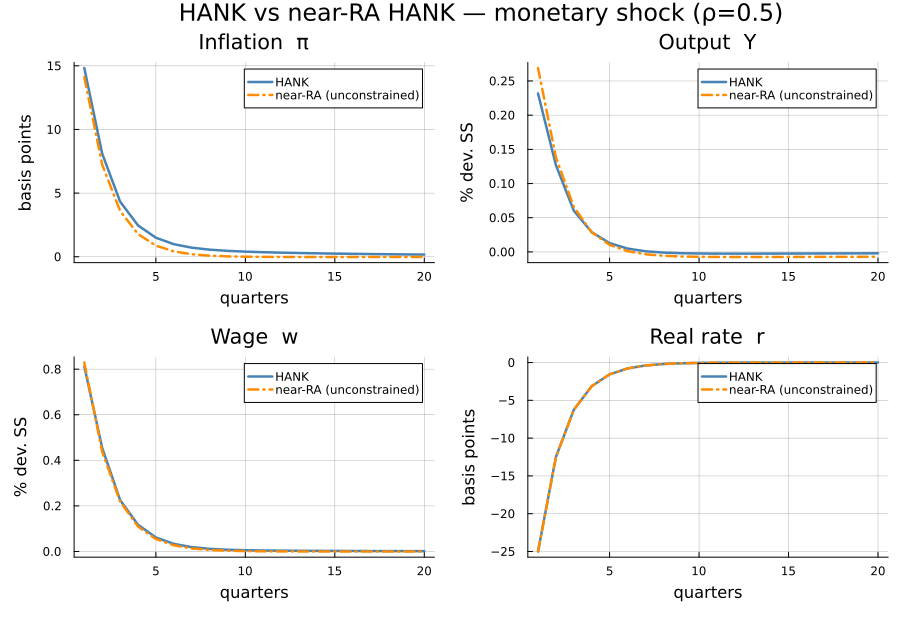

In [15]:
# ── Comparison plot: HANK vs RANK ────────────────────────────────────────────
fig = plot_hank_vs_nra(hank_irf, bench_irf, ρ_shock;
                        T_plot=20, save_path="hank_vs_benchmark.png")
display(fig)
println("Saved  →  hank_vs_benchmark.png")